<a href="https://colab.research.google.com/github/bnisarga/Artificial-Intelligence-and-neural-network/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/Stock_Price_Data_[3921] (1).csv')

In [3]:
print(df.duplicated().sum())

0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9909 entries, 1980-12-12 to 2020-04-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       9909 non-null   float64
 1   High       9909 non-null   float64
 2   Low        9909 non-null   float64
 3   Close      9909 non-null   float64
 4   Adj Close  9909 non-null   float64
 5   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 541.9 KB


In [7]:
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,9909.0,3.260685e+01,5.841576e+01,0.198661,1.071429e+00,1.729286e+00,3.580000e+01,3.247400e+02
High,9909.0,3.293608e+01,5.900158e+01,0.198661,1.089286e+00,1.758929e+00,3.626571e+01,3.278500e+02
Low,9909.0,3.227756e+01,5.788304e+01,0.196429,1.048571e+00,1.696429e+00,3.532857e+01,3.233500e+02
Close,9909.0,3.261803e+01,5.847190e+01,0.196429,1.071429e+00,1.732143e+00,3.576143e+01,3.272000e+02
Adj Close,9909.0,3.057657e+01,5.674627e+01,0.155638,9.176431e-01,1.466154e+00,3.104237e+01,3.272000e+02
Volume,9909.0,8.582916e+07,8.597195e+07,347200.000000,3.304230e+07,5.766490e+07,1.069992e+08,1.855410e+09


In [9]:
df.shape

(9909, 6)

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

In [11]:
import numpy as np
X = []
y = []

sequence_length = 60

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, 3])   # Close price index

X = np.array(X)
y = np.array(y)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

model_lstm = Sequential()

model_lstm.add(LSTM(units=64,
                    return_sequences=True,
                    input_shape=(X_train.shape[1], X_train.shape[2])))

model_lstm.add(Dropout(0.1))

model_lstm.add(LSTM(units=64))

model_lstm.add(Dropout(0.1))

model_lstm.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.4657e-05 - val_loss: 0.0011
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.9956e-05 - val_loss: 9.1668e-04
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.5436e-05 - val_loss: 0.0016
Epoch 4/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 1.5087e-05 - val_loss: 3.6064e-04
Epoch 5/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.6339e-05 - val_loss: 6.2698e-04
Epoch 6/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.4927e-05 - val_loss: 3.6956e-04
Epoch 7/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.4036e-05 - val_loss: 2.7643e-04
Epoch 8/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.5223e-05 - val_loss: 2.3768e-04
Epoch 9/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.2151e-05 - val_loss: 2.0683e-04
Epoch 10/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.3632e-05 - val_loss: 0.0010
Epoch 11/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/s

In [30]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()

model_gru.add(GRU(units=64,
                  return_sequences=True,
                  input_shape=(X_train.shape[1], X_train.shape[2])))

model_gru.add(Dropout(0.1))

model_gru.add(GRU(units=64))

model_gru.add(Dropout(0.1))

model_gru.add(Dense(1))

In [31]:
model_gru.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5.4963e-05 - val_loss: 6.8799e-04
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.7888e-05 - val_loss: 0.0014
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.7076e-05 - val_loss: 0.0014
Epoch 4/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.0865e-05 - val_loss: 3.6789e-04
Epoch 5/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.3489e-05 - val_loss: 5.3998e-04
Epoch 6/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.4852e-05 - val_loss: 6.4197e-04
Epoch 7/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.4070e-05 - val_loss: 0.0013
Epoch 8/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.2733e-05 - val_loss: 1.3389e-04
Epoch 9/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.3049e-05 - val_loss: 3.5383e-04
Epoch 10/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.2451e-05 - val_loss: 3.5322e-04
Epoch 11/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - 

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# =========================
# LSTM Predictions
# =========================

lstm_predictions = model_lstm.predict(X_test)

# Calculate Metrics
lstm_mse = mean_squared_error(y_test, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_test, lstm_predictions)

print("LSTM Results")
print("MSE :", lstm_mse)
print("RMSE:", lstm_rmse)
print("MAE :", lstm_mae)


# =========================
# GRU Predictions
# =========================

gru_predictions = model_gru.predict(X_test)

# Calculate Metrics
gru_mse = mean_squared_error(y_test, gru_predictions)
gru_rmse = np.sqrt(gru_mse)
gru_mae = mean_absolute_error(y_test, gru_predictions)

print("\nGRU Results")
print("MSE :", gru_mse)
print("RMSE:", gru_rmse)
print("MAE :", gru_mae)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
LSTM Results
MSE : 0.00015910515844643302
RMSE: 0.012613689327331359
MAE : 0.008571689493493793
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

GRU Results
MSE : 0.00013389020063354703
RMSE: 0.01157109332057896
MAE : 0.007648858508926964


In [33]:
import numpy as np

# 1. Create an empty grid of zeros matching the shape your scaler expects (1970 rows, 6 columns)
dummy_lstm = np.zeros((len(lstm_predictions), 6))

# 2. Put your predictions into the correct column slot
# If your target was the FIRST column of your dataset, use this line:
dummy_lstm[:, 0] = lstm_predictions.flatten()

# (OR: If your target was the LAST column of your dataset, uncomment the line below instead)
# dummy_lstm[:, -1] = raw_predictions.flatten()

# 3. Inverse transform the entire 6-column matrix
inverse_dummy_lstm = scaler.inverse_transform(dummy_lstm)

# 4. Extract just your prediction column back out!
predicted_prices_lstm = inverse_dummy_lstm[:, 0] # Change 0 to -1 if it was the last column

# 5. Do the exact same 5 steps for your y_test targets
dummy_actual = np.zeros((len(y_test), 6))
dummy_actual[:, 0] = y_test.flatten() # Change 0 to -1 if it was the last column
actual_prices = scaler.inverse_transform(dummy_actual)[:, 0]

In [34]:

import numpy as np

# 1. Generate the raw predictions from your trained GRU model
raw_predictions_gru = model_gru.predict(X_test)

# 2. Create an empty 6-column grid for the GRU predictions
dummy_gru = np.zeros((len(raw_predictions_gru), 6))

# 3. Place your GRU predictions into the target column slot
# (Match the index 0 or -1 to whatever you used for the LSTM step)
dummy_gru[:, 0] = raw_predictions_gru.flatten()

# 4. Inverse transform the matrix and extract the GRU price column
inverse_dummy_gru = scaler.inverse_transform(dummy_gru)
predicted_prices_gru = inverse_dummy_gru[:, 0]
print("GRU predictions successfully converted back to original prices!")

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
GRU predictions successfully converted back to original prices!


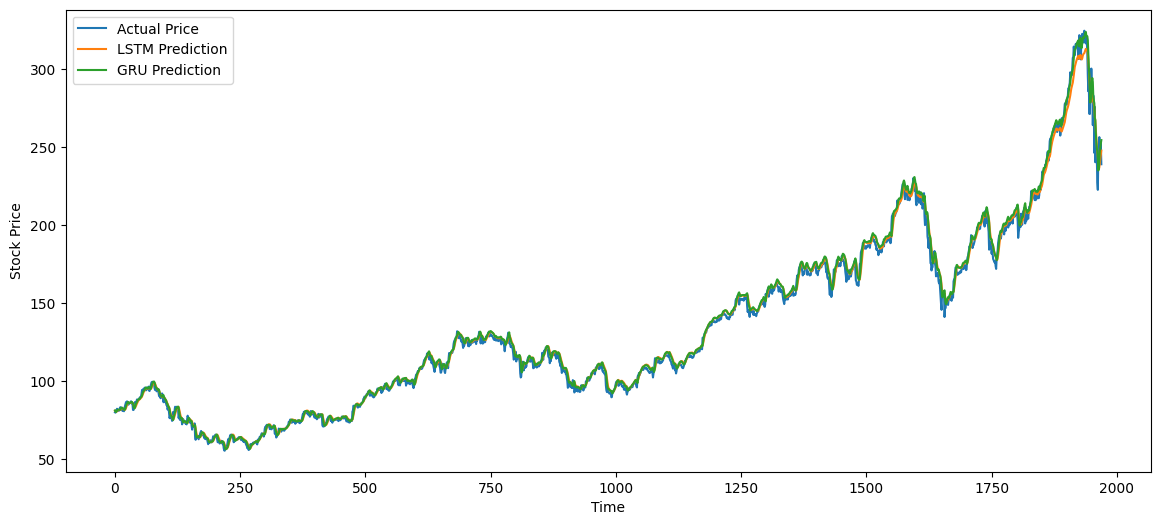

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices_lstm, label='LSTM Prediction')
plt.plot(predicted_prices_gru, label='GRU Prediction')

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.savefig('Prediction.png', dpi=1000)
plt.show()

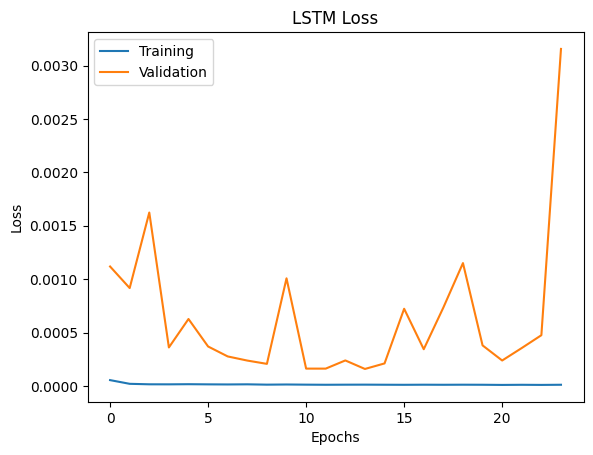

In [36]:
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.savefig('lstm loss.png',dpi=1000)
plt.show()

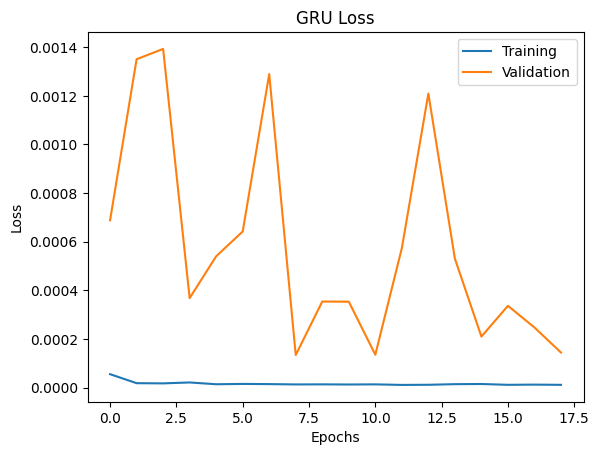

In [37]:
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])

plt.title('GRU Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.savefig('gru loss.png',dpi=1000)
plt.show()

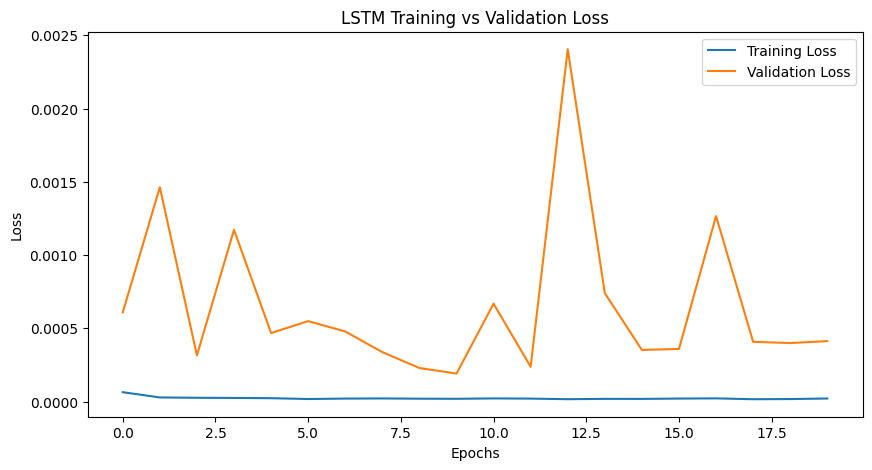

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

results_lstm = []

units_list = [32, 64]
dropout_list = [0.1, 0.2]

for units in units_list:
    for dropout in dropout_list:

        model = Sequential()

        model.add(LSTM(units,
                       return_sequences=True,
                       input_shape=(X_train.shape[1], X_train.shape[2])))

        model.add(Dropout(dropout))

        model.add(LSTM(units))

        model.add(Dropout(dropout))

        model.add(Dense(1))

        model.compile(
            optimizer='adam',
            loss='mean_squared_error'
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=20,
            batch_size=32,
            validation_data=(X_test, y_test),
            callbacks=[early_stop],
            verbose=0
        )

        best_val_loss = min(history.history['val_loss'])

        results_lstm.append([
            units,
            dropout,
            best_val_loss
        ])

lstm_tuning = pd.DataFrame(
    results_lstm,
    columns=['Units', 'Dropout', 'Validation Loss']
)

print(lstm_tuning)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Units  Dropout  Validation Loss
0     32      0.1         0.000704
1     32      0.2         0.000528
2     64      0.1         0.000166
3     64      0.2         0.000431


In [23]:
from tensorflow.keras.layers import GRU

results_gru = []

units_list = [32, 64]
dropout_list = [0.1, 0.2]

for units in units_list:
    for dropout in dropout_list:

        model = Sequential()

        model.add(GRU(units,
                      return_sequences=True,
                      input_shape=(X_train.shape[1], X_train.shape[2])))

        model.add(Dropout(dropout))

        model.add(GRU(units))

        model.add(Dropout(dropout))

        model.add(Dense(1))

        model.compile(
            optimizer='adam',
            loss='mean_squared_error'
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=20,
            batch_size=32,
            validation_data=(X_test, y_test),
            callbacks=[early_stop],
            verbose=0
        )

        best_val_loss = min(history.history['val_loss'])

        results_gru.append([
            units,
            dropout,
            best_val_loss
        ])

gru_tuning = pd.DataFrame(
    results_gru,
    columns=['Units', 'Dropout', 'Validation Loss']
)

print(gru_tuning)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Units  Dropout  Validation Loss
0     32      0.1         0.000155
1     32      0.2         0.000164
2     64      0.1         0.000128
3     64      0.2         0.000135


In [26]:
print("Best LSTM Configuration")
print(lstm_tuning.loc[lstm_tuning['Validation Loss'].idxmin()])

Best LSTM Configuration
Units              64.000000
Dropout             0.100000
Validation Loss     0.000166
Name: 2, dtype: float64


In [27]:
print("Best GRU Configuration")
print(gru_tuning.loc[gru_tuning['Validation Loss'].idxmin()])

Best GRU Configuration
Units              64.000000
Dropout             0.100000
Validation Loss     0.000128
Name: 2, dtype: float64
